<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 5.
# End-to-end: три кейса по одному чек-листу

Пять предыдущих ноутбуков разбирали SARIMAX по частям: что происходит внутри
`fit`, как выбрать порядки, чем отличаются автоматические реализации, откуда
берутся прогноз и интервал, где взять регрессоры на будущее.

Этот ноутбук — сборка. Мы один раз формулируем **чек-лист из десяти шагов** и
дальше просто прогоняем его на трёх разных рядах. Смысл упражнения не в том,
чтобы получить три модели, а в том, чтобы увидеть: шаги везде одни и те же, а
**исход каждый раз решает свой шаг**.

| Кейс | Ряд | Что в нём главное |
|---|---|---|
| **A** | дневные продажи лука (`onion_sales.csv`) | множественная сезонность; исход решила **разметка события** |
| **B** | суточный спрос на электроэнергию (`vic_elec.csv`) | нелинейный регрессор; исход решил **сценарный `exog`** |
| **C** | месячный оборот розницы (`data.tsv`) | внешний индикатор; исход решил **отказ от регрессора** |

## Чек-лист

| № | Шаг | Зачем |
|---|---|---|
| 1 | **EDA** | частота, пропуски, длина сезона, разложение STL |
| 2 | **Бейзлайн** | число, которое надо побить, иначе метрики не с чем сравнивать |
| 3 | **Стабилизация дисперсии** | логарифм / Бокс–Кокс — **до** выбора `d` |
| 4 | **`d` и `D` по тестам** | KPSS и сезонный тест, а не по AIC |
| 5 | **Кандидаты на `p, q, P, Q`** | стратегия из ноутбука `02`, выбранная под бюджет времени |
| 6 | **Подгонка и `summary()`** | интерпретация $\beta$, вменяемость коэффициентов |
| 7 | **Диагностика остатков** | Ljung–Box с `model_df`, ACF, QQ |
| 8 | **Прогноз, интервалы, покрытие** | не только точка, но и попадание в интервал |
| 9 | **Rolling-origin CV против бейзлайна** | один сплит — это одно наблюдение |
| 10 | **Вывод в бизнес-терминах** | недопрогноз/перепрогноз и что с этим делать |

> **Главное, ради чего всё это.** Чек-лист — не линейный конвейер, а **цикл**.
> В кейсе A шаг 7 покажет, что модель систематически мажет, и мы вернёмся к
> шагу 5. Один такой возврат улучшит MAPE с 14.9 % до 8.9 % — сильнее, чем
> любой перебор порядков.

## Инструмент

Основной рабочий инструмент здесь — **`statsforecast`**: в нём одной строкой
считаются и бейзлайн, и автоподбор, и интервалы, и rolling-origin CV, причём
все модели гоняются по одному и тому же протоколу. `statsmodels.SARIMAX`
оставляем там, где нужен человекочитаемый `summary()` и остатки для
диагностики.

> **Соглашение об оформлении.** 🔍 — типичная ошибка или неочевидный момент.
> ⏱ — ячейка считается заметно дольше секунды, рядом указано ожидаемое время.
> Целиком ноутбук прогоняется примерно за четыре минуты; больше половины
> этого времени — автоподбор и кросс-валидация в кейсе A.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsforecast import StatsForecast
from statsforecast.arima import arima_string, ndiffs, nsdiffs
from statsforecast.models import AutoARIMA, Naive, SeasonalNaive
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.simplefilter("ignore")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 140)

DATA = "../data/"

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/5/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


---
# 0. Инструменты: пишем один раз, используем трижды

Чтобы три кейса были сопоставимы, все вспомогательные функции определим здесь
и больше к ним не возвращаемся. Это же и есть практический смысл чек-листа:
если шаги одинаковые, то и код для них должен быть один.

## 0.1. Формат данных `statsforecast`

Напомним из ноутбука `03`: `statsforecast` работает с **длинным форматом** —
одна таблица, три обязательных столбца:

* `unique_id` — идентификатор ряда (у нас ряд один, но столбец обязателен);
* `ds` — дата;
* `y` — значение.

Регрессоры — просто дополнительные столбцы в той же таблице. Это не косметика:
библиотека рассчитана на тысячи рядов сразу, и «широкий» формат с датой в
индексе для такой задачи неудобен.

In [2]:
def to_long(y, X=None, uid="series"):
    """pd.Series (+ DataFrame регрессоров) → длинный формат statsforecast."""
    df = pd.DataFrame({"unique_id": uid, "ds": y.index, "y": np.asarray(y, dtype=float)})
    if X is not None:
        # 🔍 Самая частая ошибка при работе с exog — срез регрессоров разъехался
        # с целевым рядом на несколько наблюдений. Молча выравнивать нельзя:
        # concat допишет NaN, и ошибка всплывёт где-то глубоко внутри библиотеки.
        if len(X) != len(y):
            raise ValueError(f"длина X ({len(X)}) не совпадает с длиной y ({len(y)})")
        df = pd.concat([df, X.reset_index(drop=True)], axis=1)
    return df.reset_index(drop=True)


def exog_cols(df):
    """Имена столбцов-регрессоров в длинной таблице."""
    return [c for c in df.columns if c not in ("unique_id", "ds", "y")]

## 0.2. Детерминированные признаки

Ровно те же функции, что в ноутбуке `05`. Напомним главный паттерн: признаки,
зависящие **только от даты**, считаются один раз на сплошном индексе и потом
режутся на историю и будущее — тогда они гарантированно согласованы.

In [3]:
def extend_index(idx, h):
    """Удлиняет DatetimeIndex на h шагов вперёд с тем же шагом."""
    freq = idx.freq or pd.infer_freq(idx)
    future = pd.date_range(idx[-1], periods=h + 1, freq=freq, inclusive="right")
    return idx.append(future)


def fourier(idx, period, order, prefix="f"):
    """order пар гармоник sin/cos с заданным периодом (в шагах индекса)."""
    t = np.arange(len(idx))  # сплошная нумерация по всему индексу
    cols = {}
    for k in range(1, order + 1):
        cols[f"{prefix}_sin{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"{prefix}_cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=idx)

## 0.3. Метрики и покрытие

Три точечные метрики плюс **покрытие интервала** — доля фактов, попавших
между `lo` и `hi`. Покрытие смотрим всегда: прогноз без честного интервала
для принятия решений бесполезен, а интервалы SARIMAX систематически узки
(доказано в ноутбуке `04`, раздел 6).

In [4]:
def point_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_true - y_pred
    return {
        "MAE": np.mean(np.abs(err)),
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAPE, %": 100 * np.mean(np.abs(err / y_true)),
    }


def coverage(y_true, lo, hi):
    """Доля фактов внутри интервала, %."""
    y_true = np.asarray(y_true, float)
    return 100 * np.mean((y_true >= np.asarray(lo, float)) & (y_true <= np.asarray(hi, float)))


def scoreboard(frame, y_true, models, level=95):
    """Сводная таблица метрик по всем моделям в выдаче statsforecast."""
    rows = {}
    for m in models:
        row = point_metrics(y_true, frame[m])
        row[f"покрытие {level}%"] = coverage(y_true, frame[f"{m}-lo-{level}"], frame[f"{m}-hi-{level}"])
        rows[m] = row
    return pd.DataFrame(rows).T

## 0.4. Картинка прогноза

Одна функция вместо шести почти одинаковых блоков `fill_between`, которые
были разбросаны по исходным ноутбукам `5.5`–`5.10`.

In [5]:
def plot_forecast(y_hist, frame, model, y_true=None, level=95, tail=120, title=None, ax=None):
    """История + прогноз + интервал (+ факт, если он известен)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 3.8))
    y_hist.iloc[-tail:].plot(ax=ax, color="C0", lw=1.0, label="история")
    ds = pd.to_datetime(frame["ds"])
    ax.plot(ds, frame[model], color="C3", lw=1.6, label=f"прогноз {model}")
    ax.fill_between(
        ds, frame[f"{model}-lo-{level}"], frame[f"{model}-hi-{level}"],
        color="C3", alpha=0.18, label=f"{level}% интервал",
    )
    if y_true is not None:
        ax.plot(ds, np.asarray(y_true, float), color="k", lw=1.2, ls="--", label="факт")
    ax.set(title=title or f"Прогноз: {model}", xlabel="")
    ax.legend(loc="upper left", fontsize=8)
    return ax

## 0.5. Диагностика остатков

Три картинки и один тест — стандартный набор из ноутбука `04`:

* остатки во времени — видно смещение и всплески дисперсии;
* ACF остатков — видно, осталась ли автокорреляция;
* QQ-график — видно, нормальны ли остатки (от этого зависят интервалы);
* тест Льюнга–Бокса.

🔍 **Про `model_df`.** Тест Льюнга–Бокса проверяет гипотезу «автокорреляции
нет». Но остатки — это не наблюдения, а *результат подгонки*: модель уже
«съела» часть автокорреляции, потратив на это параметры. Если не сообщить
тесту число потраченных параметров (`model_df = p + q + P + Q`), он занизит
число степеней свободы и **слишком часто будет говорить «всё хорошо»**.

In [6]:
def residual_report(resid, n_params, lags=None, m=1, burn=0, title=""):
    """График остатков, ACF, QQ и тест Льюнга–Бокса с поправкой на model_df."""
    r = pd.Series(resid).iloc[burn:].dropna()  # первые наблюдения после дифференцирования мусорные
    lags = lags or max(10, 2 * m)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    axes[0].plot(r.values, lw=0.7, color="C0")
    axes[0].axhline(0, color="k", lw=0.8)
    axes[0].set(title=f"Остатки {title}", xlabel="")
    plot_acf(r.values, lags=lags, ax=axes[1], zero=False)
    axes[1].set(title="ACF остатков")
    qqplot(r.values, line="s", ax=axes[2], markersize=3, alpha=0.5)
    axes[2].set(title="QQ-график")
    fig.tight_layout()

    lb = acorr_ljungbox(r.values, lags=[lags], model_df=n_params)
    print(f"Ljung–Box (lags={lags}, model_df={n_params}): "
          f"stat = {lb['lb_stat'].iloc[0]:.1f}, p-value = {lb['lb_pvalue'].iloc[0]:.4f}")
    print(f"среднее остатка = {r.mean():.1f}   ст. откл. = {r.std():.1f}")
    return lb

## 0.6. Бизнес-вывод из остатков

В исходном ноутбуке `5.10` есть удачная по замыслу функция `classify()`: она
переводит среднее и разброс ошибки в фразу для отчёта руководству. Но пороги
там заданы **в абсолютных единицах** (`0.2`, `0.5`), а ряд измеряется
десятками тысяч рублей — то есть любой прогноз автоматически получает ярлык
«чрезмерное смещение, высокая дисперсия».

🔍 Это типичная ошибка: **порог, зависящий от единиц измерения**. Лечится
нормировкой — смещение и разброс считаем **в процентах от среднего уровня
ряда**, и тогда одни и те же пороги работают на рублях, гигаватт-часах и
индексах.

In [7]:
def business_summary(y_true, y_pred, bias_ok=2.0, disp_low=5.0, disp_high=15.0):
    """Смещение и разброс ошибки в % от уровня ряда + фраза для отчёта."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    scale = y_true.mean()
    bias = 100 * (y_true - y_pred).mean() / scale   # >0 — недопрогноз
    disp = 100 * (y_true - y_pred).std() / scale

    level = "умеренный" if abs(bias) <= bias_ok else "чрезмерный"
    spread = "низкая" if disp <= disp_low else ("средняя" if disp <= disp_high else "высокая")
    direction = "недопрогноз" if bias > 0 else "перепрогноз"

    action = {
        ("недопрогноз", "низкая"): "редкие дефициты, управляемая потеря продаж",
        ("недопрогноз", "средняя"): "регулярный дефицит, нужен страховой запас",
        ("недопрогноз", "высокая"): "хаотичный дефицит, риск потери клиентов",
        ("перепрогноз", "низкая"): "товар всегда в наличии, издержки хранения малы",
        ("перепрогноз", "средняя"): "периодические излишки, растут складские расходы",
        ("перепрогноз", "высокая"): "большие излишки и хаотичные поставки",
    }[(direction, spread)]

    print(f"смещение: {bias:+.1f}% от уровня ряда ({level} {direction})")
    print(f"разброс ошибки: {disp:.1f}% от уровня ряда ({spread} дисперсия)")
    print(f"→ {action}")
    return {"смещение, %": bias, "разброс, %": disp}

---
# Кейс A. Дневные продажи: множественная сезонность

Розничная сеть, ежедневная выручка по одной товарной позиции (лук), три полных
года. Горизонт прогноза — **28 дней**: столько занимает цикл планирования
закупки.

## A.1. Шаг 1 — EDA

Минимальная программа: посмотреть на ряд, проверить частоту и пропуски,
понять, какие сезонности в нём есть.

наблюдений: 1096   период: 2018-01-01 — 2020-12-31
пропусков: 0   пропущенных дат: 0
count      1096.0
mean      59941.0
std       23808.0
min        5503.0
25%       44888.0
50%       52125.0
75%       67806.0
max      184572.0


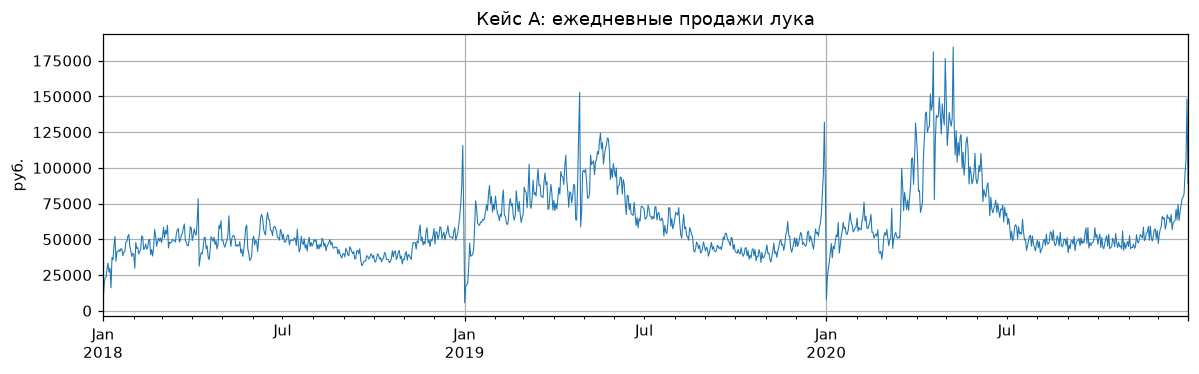

In [8]:
onion = pd.read_csv(DATA + "onion_sales.csv", parse_dates=["day"], index_col="day")["rto"]
onion.index.freq = "D"

print(f"наблюдений: {len(onion)}   период: {onion.index[0]:%Y-%m-%d} — {onion.index[-1]:%Y-%m-%d}")
print(f"пропусков: {onion.isna().sum()}   пропущенных дат: {len(pd.date_range(onion.index[0], onion.index[-1])) - len(onion)}")
print(onion.describe().round(0).to_string())

fig, ax = plt.subplots(figsize=(11, 3.5))
onion.plot(ax=ax, lw=0.7, color="C0")
ax.set(title="Кейс A: ежедневные продажи лука", ylabel="руб.", xlabel="")
fig.tight_layout()

Пропусков нет, частота дневная, ряд сплошной — уже хорошо (в реальных данных
это скорее исключение). Видно годовую волну с весенним максимумом и всплеск
в апреле–мае 2020 — это ковидный ажиотаж, к нему вернёмся.

**Какие сезонности здесь есть?** Дневной ряд почти всегда содержит недельную;
продуктовый ряд — ещё и годовую. Проверим обе, усреднив по дню недели и по
месяцу.

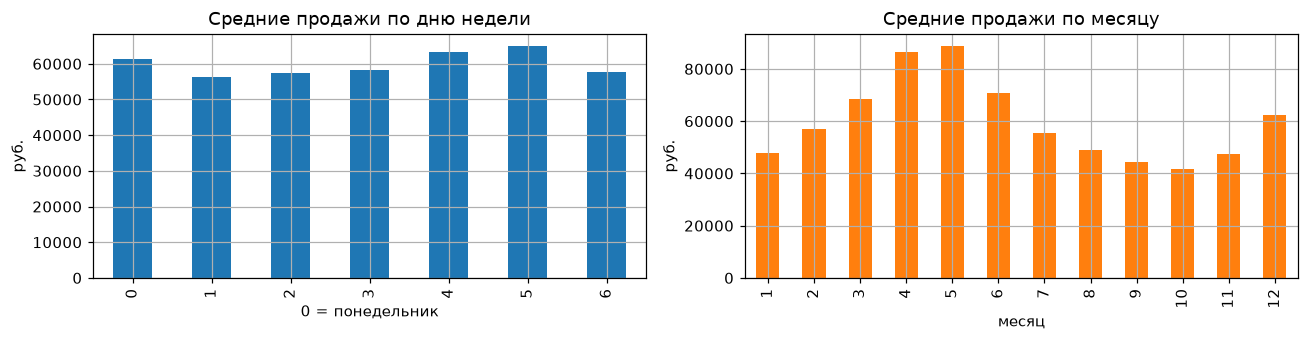

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
onion.groupby(onion.index.dayofweek).mean().plot(kind="bar", ax=axes[0], color="C0")
axes[0].set(title="Средние продажи по дню недели", xlabel="0 = понедельник", ylabel="руб.")
onion.groupby(onion.index.month).mean().plot(kind="bar", ax=axes[1], color="C1")
axes[1].set(title="Средние продажи по месяцу", xlabel="месяц", ylabel="руб.")
fig.tight_layout()

Обе сезонности реальны: недельная — размах примерно в полтора раза, годовая —
почти в два (апрель–май против сентября–октября).

Разложим ряд STL по недельному периоду, чтобы увидеть, что остаётся в тренде.

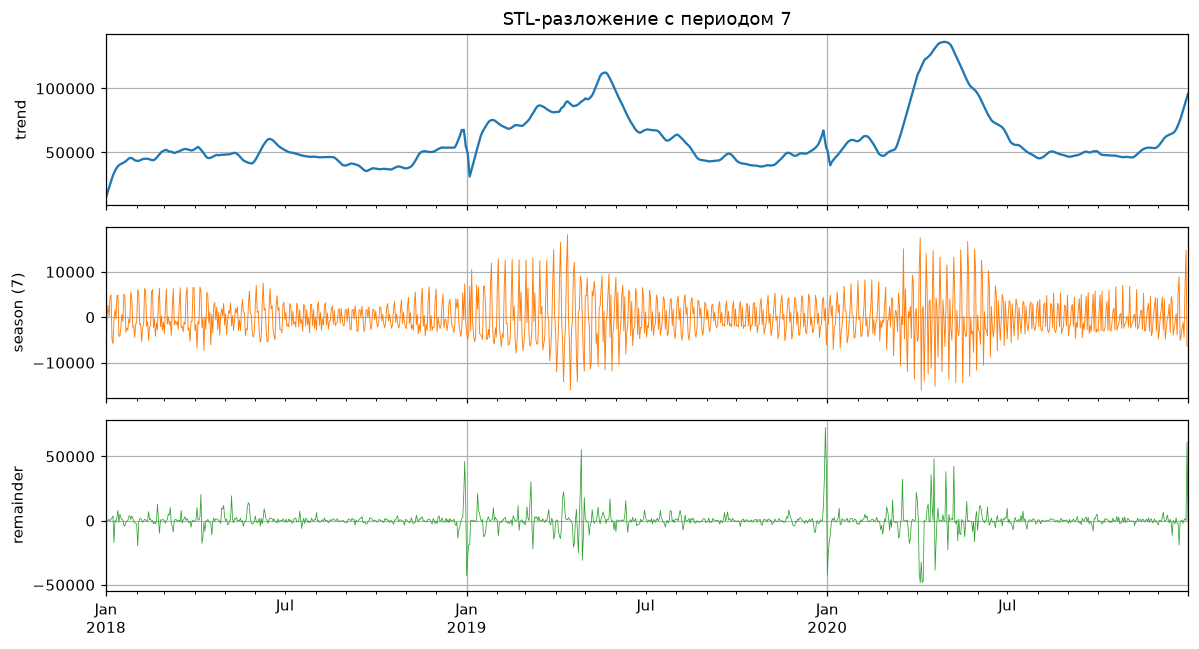

In [10]:
stl = STL(onion, period=7, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
stl.trend.plot(ax=axes[0], color="C0"); axes[0].set(ylabel="trend")
stl.seasonal.plot(ax=axes[1], color="C1", lw=0.6); axes[1].set(ylabel="season (7)")
stl.resid.plot(ax=axes[2], color="C2", lw=0.5); axes[2].set(ylabel="remainder", xlabel="")
axes[0].set_title("STL-разложение с периодом 7")
fig.tight_layout()

Тренд после снятия недельной сезонности — это и есть годовая волна плюс
ковидный всплеск. Значит, годовую сезонность придётся описывать отдельно.

🔍 **Развилка, ради которой затевался ноутбук `05`.** Сезонность с $m = 365$
SARIMA не потянет: размер вектора состояния будет ~367, обучение — десятки
минут (ноутбук `01`, раздел 3). Значит:

* **недельную** сезонность отдаём SARIMA (`season_length = 7`);
* **годовую** описываем гармониками Фурье в `exog` (ноутбук `05`, способ 1а).

## A.2. Шаг 2 — бейзлайн

Два бесплатных прогноза, которые надо побить:

* `Naive` — «завтра как сегодня»;
* `SeasonalNaive(7)` — «как в тот же день недели неделю назад».

Если модель их не бьёт, весь SARIMAX можно выбрасывать.

In [11]:
H_A = 28
y_tr_A, y_te_A = onion.iloc[:-H_A], onion.iloc[-H_A:]

sf_base = StatsForecast(models=[Naive(), SeasonalNaive(season_length=7)], freq="D")
fc_base = sf_base.forecast(df=to_long(y_tr_A, uid="onion"), h=H_A, level=[95])

scoreboard(fc_base, y_te_A, ["Naive", "SeasonalNaive"]).round(1)

,MAE,RMSE,"MAPE, %",покрытие 95%
Naive,15598.1,24177.8,18.0,100.0
SeasonalNaive,18703.6,26516.7,22.6,92.9


MAPE бейзлайнов — 18 % и 23 %. Заметьте: **сезонно-наивный оказался хуже
просто наивного.** Это не ошибка и не редкость: тестовое окно — последние 28
дней декабря, а там предновогодний рост, который «неделю назад» не описывает.
Хороший повод не считать `SeasonalNaive` автоматически сильным бейзлайном.

## A.3. Шаг 3 — стабилизация дисперсии

Смотрим, растёт ли разброс вместе с уровнем. Простой диагностический приём:
посчитать скользящие среднее и стандартное отклонение и построить одно против
другого.

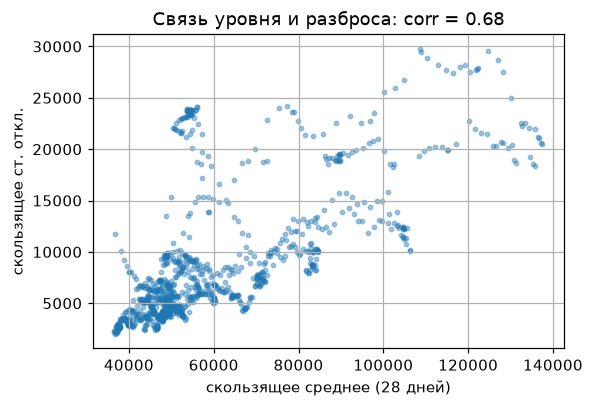

In [12]:
roll = onion.rolling(28)
mu, sd = roll.mean().dropna(), roll.std().dropna()

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.scatter(mu, sd, s=8, alpha=0.4, color="C0")
ax.set(xlabel="скользящее среднее (28 дней)", ylabel="скользящее ст. откл.",
       title=f"Связь уровня и разброса: corr = {np.corrcoef(mu, sd)[0, 1]:.2f}")
fig.tight_layout()

Корреляция 0.68 — связь есть, и учебник в этом месте советует логарифм.
Проверим совет **измерением**, а не верой: подгоним автоподбор на уровнях и
на логарифме, вернём логарифмический прогноз в рубли и сравним на тесте.

⏱ **~25 с** (два автоподбора на 1068 наблюдениях).

In [13]:
idx_A_ext = extend_index(onion.index, H_A)          # индекс с запасом на горизонт
X_A_season = pd.concat(                             # годовая + квартальная волна
    [fourier(idx_A_ext, 365.25, 3, "yr"), fourier(idx_A_ext, 91.31, 1, "qr")], axis=1
)

N_TR_A = len(y_tr_A)                                # 1068 = 1096 − 28
X_A_hist = X_A_season.iloc[:N_TR_A]                 # под обучающую выборку
X_A_fut = X_A_season.iloc[N_TR_A : N_TR_A + H_A]    # под тестовую

df_A_lvl = to_long(y_tr_A, X_A_hist, uid="onion")
X_df_A = to_long(pd.Series(np.nan, index=y_te_A.index), X_A_fut, uid="onion").drop(columns=["y"])

fc_lvl = StatsForecast([AutoARIMA(season_length=7, alias="уровни")], freq="D").forecast(
    df=df_A_lvl, h=H_A, X_df=X_df_A, level=[95]
)

df_A_log = df_A_lvl.assign(y=np.log(df_A_lvl["y"]))
fc_log = StatsForecast([AutoARIMA(season_length=7, alias="логарифм")], freq="D").forecast(
    df=df_A_log, h=H_A, X_df=X_df_A, level=[95]
)
for c in ["логарифм", "логарифм-lo-95", "логарифм-hi-95"]:
    fc_log[c] = np.exp(fc_log[c])                   # обратное преобразование

cmp_A = pd.concat([
    scoreboard(fc_lvl, y_te_A, ["уровни"]),
    scoreboard(fc_log, y_te_A, ["логарифм"]),
])
cmp_A.round(1)

,MAE,RMSE,"MAPE, %",покрытие 95%
уровни,13014.7,21101.8,14.9,89.3
логарифм,15256.0,23335.0,17.8,92.9


Логарифм **не помог**: MAPE 17.8 % против 14.9 % на уровнях. Так бывает, и
причина здесь содержательная — рост дисперсии в этом ряду вызван не
мультипликативностью, а двумя всплесками (ковид и Новый год), которые
логарифм не лечит, а размазывает.

🔍 Два важных технических момента про логарифм, о которых обычно забывают:

1. **AIC модели на логарифмах несравним с AIC модели на уровнях** — это
   правдоподобия разных рядов. Сравнивать можно только метрики после
   обратного преобразования, что мы и сделали.
2. $\exp$ от прогноза логарифма — это прогноз **медианы**, а не среднего.
   Для среднего нужна поправка $\exp(\hat y + \hat\sigma^2/2)$. Для интервала
   поправка не нужна: границы квантилей преобразуются как есть.

**Решение по шагу 3: работаем на уровнях.**

## A.4. Шаг 4 — `d` и `D` по тестам

Порядки дифференцирования выбираются **тестами**, а не критерием (ноутбук
`02`, раздел 1). В `statsforecast` те же тесты, что внутри `AutoARIMA`,
доступны напрямую.

In [14]:
print(f"d (KPSS)            = {ndiffs(onion.values)}")
print(f"D (сезонный тест, m=7) = {nsdiffs(onion.values, period=7)}")

d (KPSS)            = 1
D (сезонный тест, m=7) = 0


$d = 1$, $D = 0$: ряд нестационарен по уровню, но недельная сезонность
устойчива и сезонной разности не требует. Это ровно то, что мы видели на STL.

## A.5. Шаг 5 — кандидаты на порядки

Стратегия из ноутбука `02` выбирается под бюджет. Ряд длинный (1068
наблюдений), полный перебор по `p, q, P, Q` здесь стоил бы часы, поэтому
берём **стратегию D — пошаговый автоподбор** (Хайндман–Хандакар).

Регрессоры — гармоники Фурье, которые мы уже собрали: 3 пары на годовом
периоде и 1 пара на квартальном.

In [15]:
model_A1 = AutoARIMA(season_length=7, alias="A1")
sf_A1 = StatsForecast([model_A1], freq="D")
sf_A1.fit(df=df_A_lvl)

print("выбранная спецификация:", arima_string(sf_A1.fitted_[0, 0].model_))
print("регрессоры:", ", ".join(exog_cols(df_A_lvl)))

выбранная спецификация: Regression with ARIMA(3,1,3)(0,0,2)[7] errors
регрессоры: yr_sin1, yr_cos1, yr_sin2, yr_cos2, yr_sin3, yr_cos3, qr_sin1, qr_cos1


`Regression with ARIMA(3,1,3)(0,0,2)[7] errors` — «регрессия с
SARIMA-ошибками», ровно та запись, которую мы разбирали в ноутбуке `04`,
раздел 3.

## A.6. Шаг 6 — подгонка и `summary()`

Автоподбор уже дал порядок. Теперь подгоним ту же спецификацию в
`statsmodels`, чтобы получить человекочитаемые коэффициенты и остатки
(`statsforecast` оптимизирован под скорость и такой таблицы не печатает).

In [16]:
ORDER_A1, SORDER_A1 = (3, 1, 3), (0, 0, 2, 7)

m_A1 = SARIMAX(y_tr_A, exog=X_A_hist, order=ORDER_A1, seasonal_order=SORDER_A1).fit(disp=False)
print(m_A1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
yr_sin1     2.476e+04   1.11e+04      2.237      0.025    3068.672    4.65e+04
yr_cos1    -7499.6345   8912.813     -0.841      0.400    -2.5e+04    9969.157
yr_sin2    -4790.5109   5643.260     -0.849      0.396   -1.59e+04    6270.076
yr_cos2    -1546.8734   6262.699     -0.247      0.805   -1.38e+04    1.07e+04
yr_sin3     1399.8485   4087.220      0.342      0.732   -6610.955    9410.652
yr_cos3     4633.6450   4473.751      1.036      0.300   -4134.746    1.34e+04
qr_sin1     2149.8754   2975.964      0.722      0.470   -3682.907    7982.657
qr_cos1    -1282.2411   2711.901     -0.473      0.636   -6597.468    4032.986
ar.L1         -1.2348      0.027    -45.179      0.000      -1.288      -1.181
ar.L2         -0.0038      0.036     -0.106      0.915      -0.074       0.066
ar.L3          0.5070      0.025     20.304      0.0

Отдельные $\beta$ при `yr_sin1`, `yr_cos1`, … интерпретировать бессмысленно:
это коэффициенты при синусах и косинусах, а не при осмысленных величинах.
Смысл есть у **их суммы** — она и есть восстановленный сезонный профиль года.
Нарисуем его.

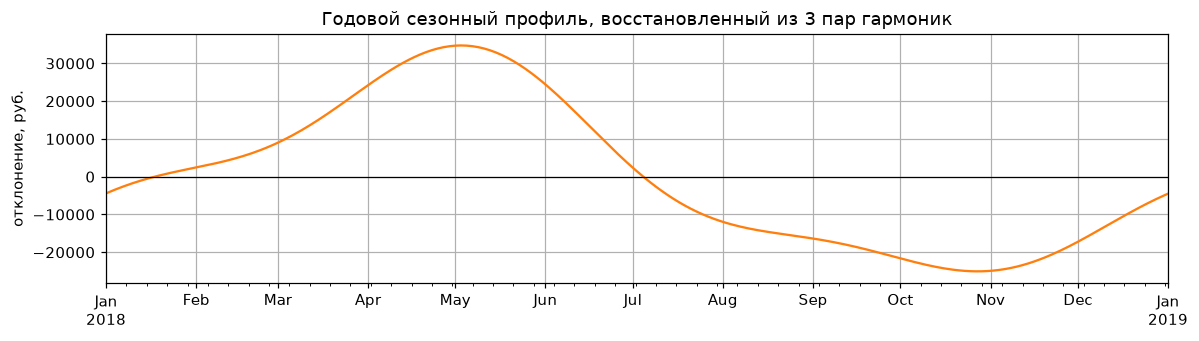

In [17]:
yr_cols = [c for c in X_A_hist.columns if c.startswith("yr")]
season_year = X_A_season[yr_cols] @ m_A1.params[yr_cols]

fig, ax = plt.subplots(figsize=(11, 3.2))
season_year.iloc[:366].plot(ax=ax, color="C1")
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Годовой сезонный профиль, восстановленный из 3 пар гармоник",
       ylabel="отклонение, руб.", xlabel="")
fig.tight_layout()

Гладкая волна с максимумом весной и минимумом осенью — содержательно
правдоподобно. Заодно видно **ограничение метода**: три гармоники дают только
плавную кривую, резкий пик она описать не может. Запомним это.

## A.7. Шаг 7 — диагностика остатков

Пропускаем первые наблюдения: после дифференцирования и «разгона» фильтра
Калмана они не несут информации.

Ljung–Box (lags=14, model_df=8): stat = 41.3, p-value = 0.0000
среднее остатка = 122.7   ст. откл. = 8674.9


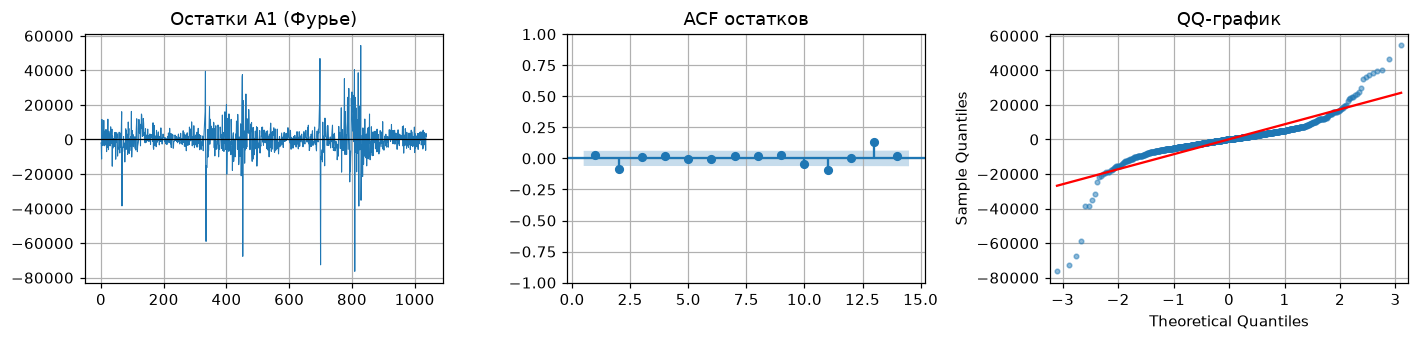

In [18]:
n_par_A1 = sum(ORDER_A1[::2]) + SORDER_A1[0] + SORDER_A1[2]   # p+q+P+Q
_ = residual_report(m_A1.resid, n_params=n_par_A1, m=7, burn=30, title="A1 (Фурье)")

Читаем картинку:

* **ACF** — несколько лагов торчат за доверительную полосу, Ljung–Box
  уверенно отвергается ($p < 0.001$). Структура в остатках осталась;
* **QQ-график** — тяжёлые хвосты: точки на краях резко уходят от прямой;
* **график остатков** — и вот здесь главное: несколько гигантских выбросов,
  и все они сгруппированы.

🔍 Соблазн на этом месте — начать наращивать `p` и `q`, чтобы «дочистить» ACF.
Но тяжёлые хвосты и сгруппированные выбросы — это подпись не пропущенного
лага, а **пропущенного события**. Поэтому вместо теста смотрим на конкретные
даты: когда именно модель мажет сильнее всего.

In [19]:
res_A1 = pd.Series(m_A1.resid, index=y_tr_A.index).iloc[30:]
worst = res_A1.abs().nlargest(10).sort_index()
print("Десять худших дней:")
print(pd.DataFrame({"остаток, руб.": res_A1[worst.index].round(0)}).to_string())

Десять худших дней:
            остаток, руб.
day                      
2018-12-30        39478.0
2019-01-01       -58986.0
2019-04-28       -67642.0
2019-12-30        46865.0
2020-01-01       -72552.0
2020-04-18        40416.0
2020-04-19       -76316.0
2020-04-30        38614.0
2020-05-02       -38547.0
2020-05-08        54418.0


🔑 **Вот оно.** Крупнейшие промахи — **конец декабря и первые дни января**
(плюс апрель 2020 — ковид). Это не случайный шум, а регулярное событие,
которое повторяется каждый год и которое три гладкие гармоники описать не
могут: предновогодний пик слишком острый.

Именно поэтому чек-лист — цикл. Диагностика нашла содержательную проблему —
**возвращаемся к шагу 5** и добавляем то, чего не хватает: дамми на событие
(ноутбук `05`, способ 6).

## A.5′. Возврат к шагу 5 — дамми на новогодний период

Два признака, оба считаются из календаря и потому известны на любой горизонт
вперёд (способ 1 из ноутбука `05`):

* `pre_ny` — 28–31 декабря, закупка к столу;
* `post_ny` — 1–3 января, провал после праздника.

In [20]:
def ny_dummies(idx):
    """Дамми на предновогодний ажиотаж и послепраздничный провал."""
    return pd.DataFrame(
        {
            "pre_ny": ((idx.month == 12) & (idx.day >= 28)).astype(float),
            "post_ny": ((idx.month == 1) & (idx.day <= 3)).astype(float),
        },
        index=idx,
    )


X_A_full = pd.concat([X_A_season, ny_dummies(idx_A_ext)], axis=1)   # считаем на удлинённом индексе
X_A2_hist = X_A_full.iloc[:N_TR_A]
X_A2_fut = X_A_full.iloc[N_TR_A : N_TR_A + H_A]

df_A2 = to_long(y_tr_A, X_A2_hist, uid="onion")
X_df_A2 = to_long(pd.Series(np.nan, index=y_te_A.index), X_A2_fut, uid="onion").drop(columns=["y"])

sf_A2 = StatsForecast([AutoARIMA(season_length=7, alias="A2")], freq="D")
sf_A2.fit(df=df_A2)
print("новая спецификация:", arima_string(sf_A2.fitted_[0, 0].model_))

новая спецификация: Regression with ARIMA(1,1,1)(2,0,1)[7] errors


In [21]:
ORDER_A2, SORDER_A2 = (1, 1, 1), (2, 0, 1, 7)
m_A2 = SARIMAX(y_tr_A, exog=X_A2_hist, order=ORDER_A2, seasonal_order=SORDER_A2).fit(disp=False)

print(f"β(pre_ny)  = {m_A2.params['pre_ny']:+,.0f} руб./день")
print(f"β(post_ny) = {m_A2.params['post_ny']:+,.0f} руб./день")
print(f"AIC: A1 = {m_A1.aic:.0f} → A2 = {m_A2.aic:.0f}")

β(pre_ny)  = +33,029 руб./день
β(post_ny) = -16,353 руб./день
AIC: A1 = 22410 → A2 = 22246


Коэффициенты читаются напрямую, как в обычной регрессии (ноутбук `04`, п. 3):
в предновогодние дни продажи выше базовой линии примерно на 33 тыс. руб. в
день, в первые дни января — ниже на 16 тыс. Это уже число для закупщика.

Заметьте и другое: порядок ARIMA **упростился** с $(3,1,3)(0,0,2)_7$ до
$(1,1,1)(2,0,1)_7$. Так обычно и бывает: когда в `exog` появляется то, что
ряд действительно объясняет, авторегрессии больше не нужно это компенсировать
длинными лагами.

Ljung–Box (lags=14, model_df=5): stat = 78.0, p-value = 0.0000
среднее остатка = -60.0   ст. откл. = 7927.0


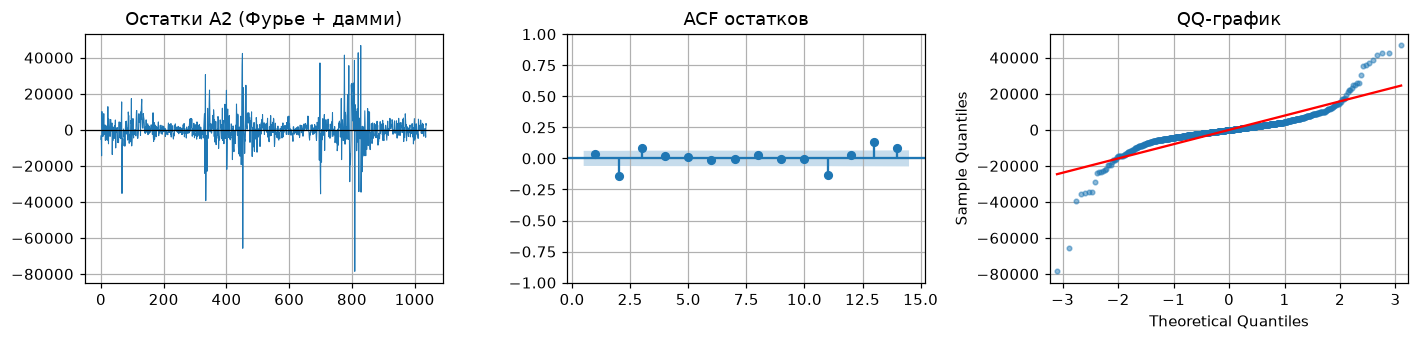

In [22]:
_ = residual_report(m_A2.resid, n_params=sum(ORDER_A2[::2]) + SORDER_A2[0] + SORDER_A2[2],
                    m=7, burn=30, title="A2 (Фурье + дамми)")

In [23]:
res_A2 = pd.Series(m_A2.resid, index=y_tr_A.index).iloc[30:]
ny_mask = ((res_A1.index.month == 12) & (res_A1.index.day >= 28)) | \
          ((res_A1.index.month == 1) & (res_A1.index.day <= 3))

pd.DataFrame(
    {
        "средний |остаток| в новогодние дни": [res_A1[ny_mask].abs().mean(), res_A2[ny_mask].abs().mean()],
        "средний |остаток| в остальные дни": [res_A1[~ny_mask].abs().mean(), res_A2[~ny_mask].abs().mean()],
    },
    index=["A1 (Фурье)", "A2 (Фурье + дамми)"],
).round(0)

,средний |остаток| в новогодние дни,средний |остаток| в остальные дни
A1 (Фурье),27640.0,4802.0
A2 (Фурье + дамми),18732.0,4365.0


Вот это и есть эффект дамми: в новогодние дни средняя ошибка упала примерно
на треть, в остальные дни почти не изменилась. То есть дамми сработала
адресно — ровно там, где мы её поставили, и не испортила всё остальное.

Абсолютная величина ошибки в праздники всё равно осталась высокой (18.7 тыс.
против 4.4 тыс. в обычные дни): три года истории — это всего три Новых года,
и оценить по ним эффект точно невозможно. Но даже такая грубая поправка
радикально меняет прогноз, как видно ниже.

🔍 А вот Ljung–Box у A2 **не улучшился** — он по-прежнему отвергается. Так
бывает: автоподбор, получив в `exog` объяснение новогоднего всплеска, выбрал
более простой порядок $(1,1,1)(2,0,1)_7$ вместо $(3,1,3)(0,0,2)_7$, и
короткая автокорреляция в остатках сохранилась. Формальный тест стал хуже,
а прогноз, как мы сейчас увидим, — лучше почти вдвое.

Мораль: **диагностика остатков нужна, чтобы найти пропущенную структуру, а не
чтобы ранжировать модели.** Ранжируют по метрике на отложенной выборке.

## A.8. Шаг 8 — прогноз, интервалы, покрытие

In [24]:
fc_A2 = StatsForecast([AutoARIMA(season_length=7, alias="A2")], freq="D").forecast(
    df=df_A2, h=H_A, X_df=X_df_A2, level=[95]
)

tab_A = pd.concat([
    scoreboard(fc_base, y_te_A, ["Naive", "SeasonalNaive"]),
    scoreboard(fc_lvl, y_te_A, ["уровни"]).rename(index={"уровни": "A1: Фурье"}),
    scoreboard(fc_A2, y_te_A, ["A2"]).rename(index={"A2": "A2: Фурье + дамми"}),
])
tab_A.round(1)

,MAE,RMSE,"MAPE, %",покрытие 95%
Naive,15598.1,24177.8,18.0,100.0
SeasonalNaive,18703.6,26516.7,22.6,92.9
A1: Фурье,13014.7,21101.8,14.9,89.3
A2: Фурье + дамми,7316.9,10972.3,8.9,96.4


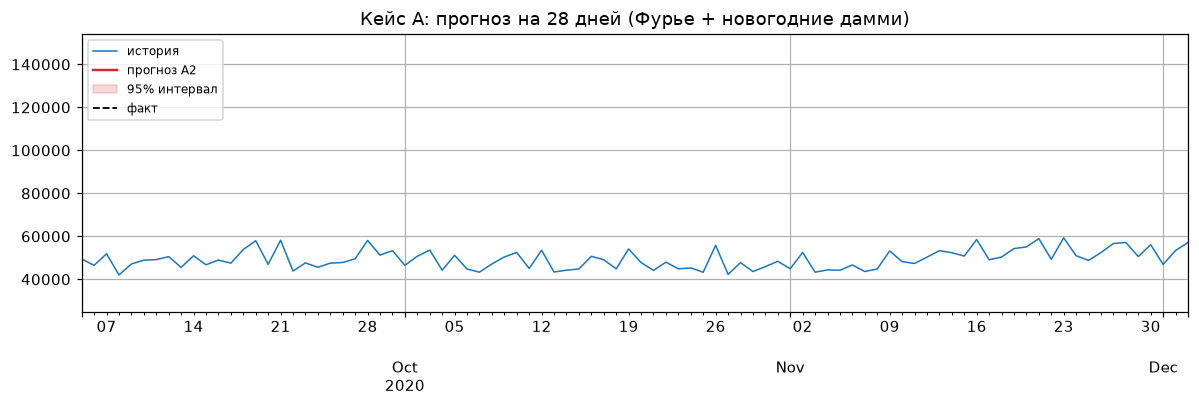

In [25]:
plot_forecast(y_tr_A, fc_A2, "A2", y_true=y_te_A, tail=90,
              title="Кейс A: прогноз на 28 дней (Фурье + новогодние дамми)")
plt.tight_layout()

Итог одного возврата к шагу 5:

| | MAPE | покрытие 95 % |
|---|---|---|
| `Naive` | 18.0 % | — |
| A1: только Фурье | 14.9 % | 89 % |
| **A2: Фурье + дамми** | **8.9 %** | **96 %** |

Ошибка упала почти вдвое, а интервал из заниженного стал честным. Ни один
перебор порядков такого эффекта не даёт: **содержательный регрессор сильнее
любой настройки `(p,q,P,Q)`.**

## A.9. Шаг 9 — rolling-origin CV

Один тестовый отрезок — это одно наблюдение, и в кейсе A оно вдобавок
нетипичное (Новый год). Проверим на трёх последовательных окнах по 28 дней.

⏱ **~1 мин**: три окна × два автоподбора, каждый раз модель переобучается
заново.

In [26]:
df_A_cv = to_long(onion, X_A_full.iloc[: len(onion)], uid="onion")

cv_A = StatsForecast(
    models=[SeasonalNaive(season_length=7), AutoARIMA(season_length=7, alias="A2")], freq="D"
).cross_validation(df=df_A_cv, h=H_A, n_windows=3, step_size=H_A, level=[95])

print("окна:", ", ".join(str(c)[:10] for c in sorted(cv_A["cutoff"].unique())))
scoreboard(cv_A, cv_A["y"], ["SeasonalNaive", "A2"]).round(1)

окна: 2020-10-08, 2020-11-05, 2020-12-03


,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,9102.7,15918.7,13.1,97.6
A2,5757.4,7906.8,9.6,98.8


На трёх окнах картина устойчивая: модель уверенно бьёт бейзлайн и по точке, и
по покрытию. Именно это число, а не результат одного сплита, стоит показывать
заказчику.

### Боевой прогноз: за пределы имеющихся данных

Всё, что было выше, — прогноз внутрь данных, чтобы было с чем сравнивать.
В работе нужен прогноз **за последнюю дату**, и вот здесь и пригождается
`extend_index`: признаки для будущих 28 дней берутся из тех же 1124 строк,
которые мы посчитали один раз в начале.

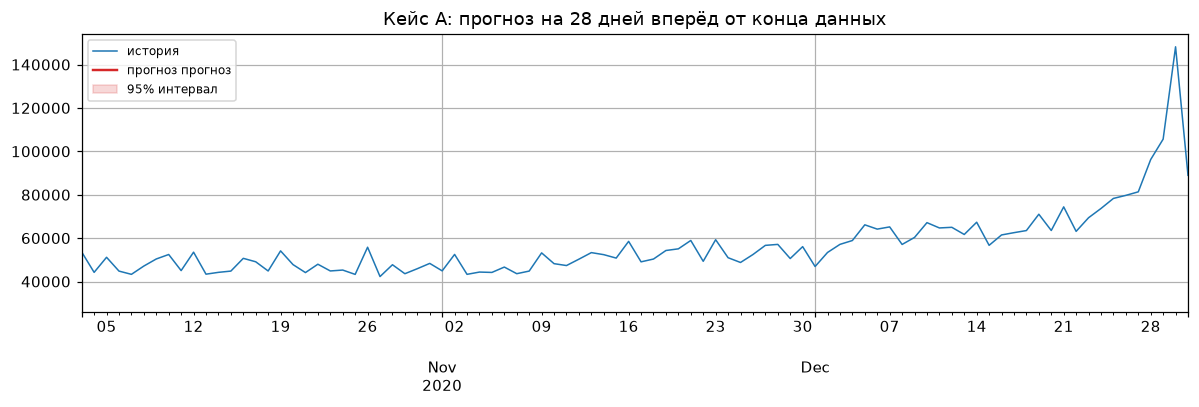

In [27]:
X_A_prod_hist = X_A_full.iloc[: len(onion)]          # вся история
X_A_prod_fut = X_A_full.iloc[len(onion) :]           # 28 дней за пределами данных

fc_prod = StatsForecast([AutoARIMA(season_length=7, alias="прогноз")], freq="D").forecast(
    df=to_long(onion, X_A_prod_hist, uid="onion"),
    h=H_A,
    X_df=to_long(pd.Series(np.nan, index=idx_A_ext[-H_A:]), X_A_prod_fut, uid="onion").drop(columns=["y"]),
    level=[95],
)

plot_forecast(onion, fc_prod, "прогноз", tail=90,
              title="Кейс A: прогноз на 28 дней вперёд от конца данных")
plt.tight_layout()

## A.10. Шаг 10 — вывод в бизнес-терминах

In [28]:
_ = business_summary(y_te_A, fc_A2["A2"])

смещение: +7.0% от уровня ряда (чрезмерный недопрогноз)
разброс ошибки: 13.4% от уровня ряда (средняя дисперсия)
→ регулярный дефицит, нужен страховой запас


**Вывод по кейсу A.** Дневной ряд с двумя сезонностями прогнозируется SARIMAX
с точностью около 9 % MAPE на горизонте четырёх недель. Недельную сезонность
описывает сама SARIMA, годовую — три пары гармоник Фурье, предновогодний
всплеск — две дамми. Решающим оказался **шаг 7**: без диагностики остатков мы
бы сдали модель с вдвое большей ошибкой и заниженным интервалом.

---
# Кейс B. Спрос на электроэнергию: сценарные регрессоры

Суточное потребление электроэнергии в штате Виктория (Австралия) за 2014 год.
Здесь регрессор не календарный, а **физический** — температура, и она в
будущем неизвестна. Горизонт — **14 дней**.

## B.1. Шаг 1 — EDA

наблюдений: 365   период: 2014-01-01 — 2014-12-31
пропусков: 0   праздников: 10


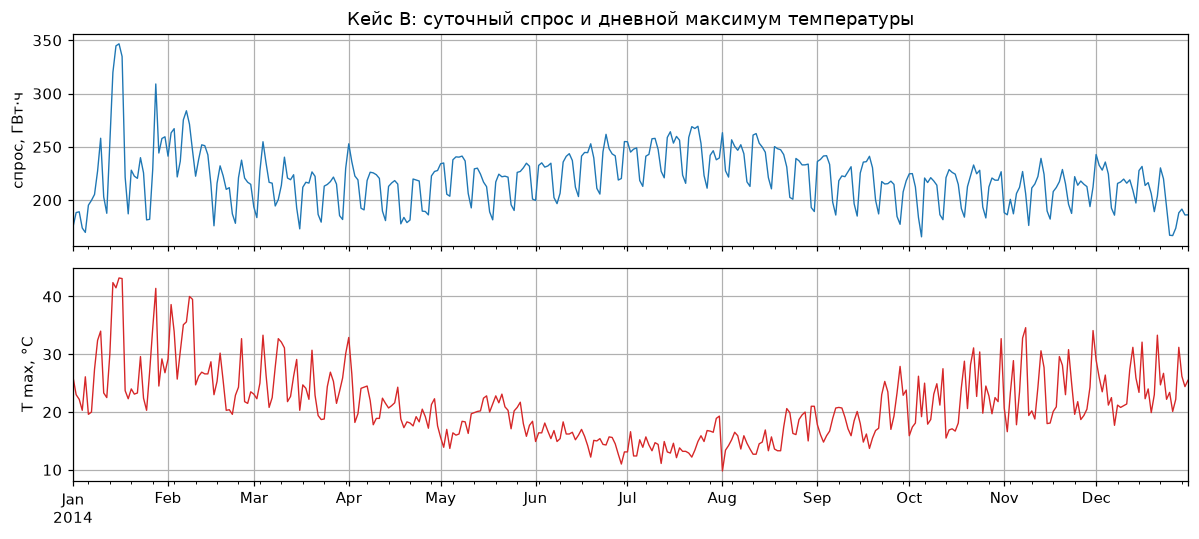

In [29]:
raw = pd.read_csv(DATA + "vic_elec.csv", parse_dates=["Time"])
raw["Date"] = pd.to_datetime(raw["Date"])

daily = raw.groupby("Date").agg(                 # получасовые данные → суточные
    Demand=("Demand", "sum"),
    Temperature=("Temperature", "max"),          # дневной максимум — он и включает кондиционеры
    Holiday=("Holiday", "first"),
)
daily.index.freq = "D"
daily["Demand"] /= 1000                          # ГВт·ч

vic = daily.loc["2014"]
print(f"наблюдений: {len(vic)}   период: {vic.index[0]:%Y-%m-%d} — {vic.index[-1]:%Y-%m-%d}")
print(f"пропусков: {int(vic.isna().sum().sum())}   праздников: {int(vic['Holiday'].sum())}")

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
vic["Demand"].plot(ax=axes[0], color="C0", lw=0.9); axes[0].set(ylabel="спрос, ГВт·ч")
vic["Temperature"].plot(ax=axes[1], color="C3", lw=0.9); axes[1].set(ylabel="T max, °C", xlabel="")
axes[0].set_title("Кейс B: суточный спрос и дневной максимум температуры")
fig.tight_layout()

Ряд короткий — один год, 365 наблюдений. Годовой сезонности здесь не измерить
(нет ни одного полного повторения), поэтому остаётся **недельная**, $m = 7$.
А сезон года входит в модель иначе — через температуру.

Посмотрим на связь спроса и температуры.

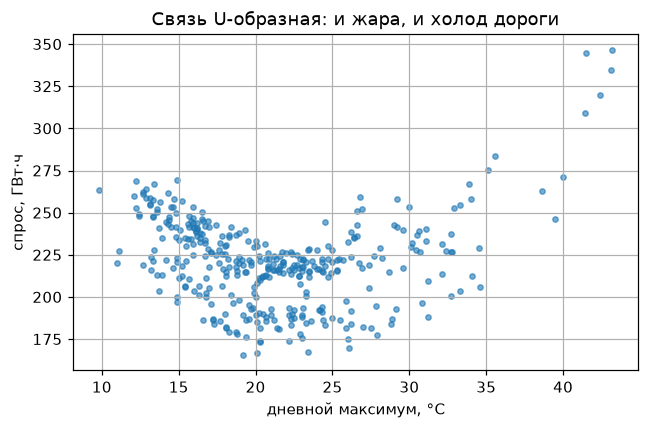

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(vic["Temperature"], vic["Demand"], s=12, alpha=0.6, color="C0")
ax.set(xlabel="дневной максимум, °C", ylabel="спрос, ГВт·ч",
       title="Связь U-образная: и жара, и холод дороги")
fig.tight_layout()

Связь **нелинейная и U-образная**: в холод включают обогрев, в жару —
кондиционеры. Линейный член её не опишет — нужен ещё и квадрат температуры.

## B.2. Шаг 2 — бейзлайн

Годовой сезонности нет, поэтому бейзлайн один — `SeasonalNaive(7)`.

In [31]:
H_B = 14
y_B = vic["Demand"]
y_tr_B, y_te_B = y_B.iloc[:-H_B], y_B.iloc[-H_B:]

fc_base_B = StatsForecast([SeasonalNaive(season_length=7)], freq="D").forecast(
    df=to_long(y_tr_B, uid="vic"), h=H_B, level=[95]
)
scoreboard(fc_base_B, y_te_B, ["SeasonalNaive"]).round(2)

,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,23.57,29.03,12.97,100.0


## B.3. Шаг 3 — стабилизация дисперсии

Проверяем так же, как в кейсе A.

In [32]:
roll_B = y_B.rolling(28)
mu_B, sd_B = roll_B.mean().dropna(), roll_B.std().dropna()
print(f"corr(среднее, ст. откл.) = {np.corrcoef(mu_B, sd_B)[0, 1]:.2f}")
print(f"размах уровня: {y_B.min():.0f} — {y_B.max():.0f} ГВт·ч (в {y_B.max() / y_B.min():.1f} раза)")

corr(среднее, ст. откл.) = 0.41
размах уровня: 166 — 347 ГВт·ч (в 2.1 раза)


Связь слабая (0.41), размах уровня двукратный. Но главное здесь другое:
и уровень, и разброс тянет **температура**, а её мы собираемся включить в
модель явным регрессором. Логарифм в такой ситуации — лечение симптома вместо
причины, поэтому **преобразование не делаем**.

🔍 Это важный пункт: шаг чек-листа можно пропустить, но пропустить его нужно
**осознанно, с числом в руках и с объяснением**. «Логарифмируем на всякий
случай» — плохая практика: в кейсе A такой «всякий случай» ухудшил бы MAPE
на три пункта.

## B.4. Шаг 4 — `d` и `D`

In [33]:
print(f"d (KPSS)               = {ndiffs(y_B.values)}")
print(f"D (сезонный тест, m=7) = {nsdiffs(y_B.values, period=7)}")

d (KPSS)               = 1
D (сезонный тест, m=7) = 1


## B.5. Шаг 5 — кандидаты и регрессоры

Три регрессора:

* `temp` и `temp2` — температура и её квадрат (та самая парабола);
* `workday` — рабочий день: не выходной и не праздник.

Праздники известны по календарю на годы вперёд (способ 2 из ноутбука `05`),
а вот температура — нет. С ней разберёмся на шаге 8.

In [34]:
def vic_exog(index, temperature, holiday):
    """Регрессоры модели спроса. index / temperature / holiday — одной длины."""
    weekend = pd.Index(index).dayofweek.isin([5, 6])
    temperature = np.asarray(temperature, dtype=float)
    return pd.DataFrame(
        {
            "temp": temperature,
            "temp2": temperature**2,
            "workday": (~(np.asarray(holiday, dtype=bool) | weekend)).astype(float),
        },
        index=index,
    )


X_B = vic_exog(vic.index, vic["Temperature"], vic["Holiday"])
X_tr_B, X_te_B = X_B.iloc[:-H_B], X_B.iloc[-H_B:]

df_B = to_long(y_tr_B, X_tr_B, uid="vic")
X_df_B = to_long(pd.Series(np.nan, index=y_te_B.index), X_te_B, uid="vic").drop(columns=["y"])

sf_B = StatsForecast([AutoARIMA(season_length=7, alias="B")], freq="D")
sf_B.fit(df=df_B)
print("с регрессорами:", arima_string(sf_B.fitted_[0, 0].model_))

sf_B0 = StatsForecast([AutoARIMA(season_length=7, alias="B0")], freq="D")
sf_B0.fit(df=df_B[["unique_id", "ds", "y"]])
print("без регрессоров:", arima_string(sf_B0.fitted_[0, 0].model_))

с регрессорами: Regression with ARIMA(2,1,2)(2,0,1)[7] errors


без регрессоров: ARIMA(1,0,2)(0,1,1)[7]                   


🔍 Обратите внимание: **без регрессоров автоподбор берёт сезонную разность**
$(0,1,1)_7$, а с регрессорами обходится без неё. Логично: часть недельного
ритма уже объяснена признаком `workday`, и сезонной разности больше нечего
убирать. Порядок модели зависит от набора `exog` — сравнивать спецификации в
отрыве от регрессоров бессмысленно.

## B.6. Шаг 6 — подгонка и интерпретация $\beta$

In [35]:
ORDER_B, SORDER_B = (2, 1, 2), (2, 0, 1, 7)
m_B = SARIMAX(y_tr_B, exog=X_tr_B, order=ORDER_B, seasonal_order=SORDER_B).fit(disp=False)
print(m_B.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp          -7.9618      0.420    -18.969      0.000      -8.784      -7.139
temp2          0.1864      0.008     23.726      0.000       0.171       0.202
workday       31.7964      1.450     21.924      0.000      28.954      34.639
ar.L1         -0.0465      0.160     -0.291      0.771      -0.359       0.266
ar.L2          0.7345      0.126      5.829      0.000       0.488       0.981
ma.L1         -0.0681      0.127     -0.534      0.593      -0.318       0.182
ma.L2         -0.9063      0.125     -7.276      0.000      -1.150      -0.662
ar.S.L7        0.7406      0.088      8.433      0.000       0.568       0.913
ar.S.L14       0.1947      0.071      2.742      0.006       0.056       0.334
ma.S.L7       -0.6601      0.084     -7.896      0.000      -0.824      -0.496
sigma2        39.2894      2.106     18.657      0.0

In [36]:
t_min = -m_B.params["temp"] / (2 * m_B.params["temp2"])
print(f"минимум спроса достигается при T ≈ {t_min:.1f} °C")
print(f"рабочий день дороже нерабочего на {m_B.params['workday']:.1f} ГВт·ч")
print(f"рост с {t_min:.0f} до 40 °C добавляет "
      f"{m_B.params['temp'] * (40 - t_min) + m_B.params['temp2'] * (40**2 - t_min**2):.0f} ГВт·ч")

минимум спроса достигается при T ≈ 21.4 °C
рабочий день дороже нерабочего на 31.8 ГВт·ч
рост с 21 до 40 °C добавляет 65 ГВт·ч


Все три числа проверяемы здравым смыслом: минимум потребления — около 21 °C
(ни обогрев, ни кондиционер не нужны), рабочий день дороже выходного, жара
в 40 °C добавляет к спросу десятки гигаватт-часов. Если бы минимум оказался
при −5 °C или `workday` вышел отрицательным, это был бы сигнал, что модель
собрана неправильно, — и никакие метрики этого бы не показали.

## B.7. Шаг 7 — диагностика остатков

Ljung–Box (lags=14, model_df=7): stat = 26.6, p-value = 0.0004
среднее остатка = -0.0   ст. откл. = 6.1


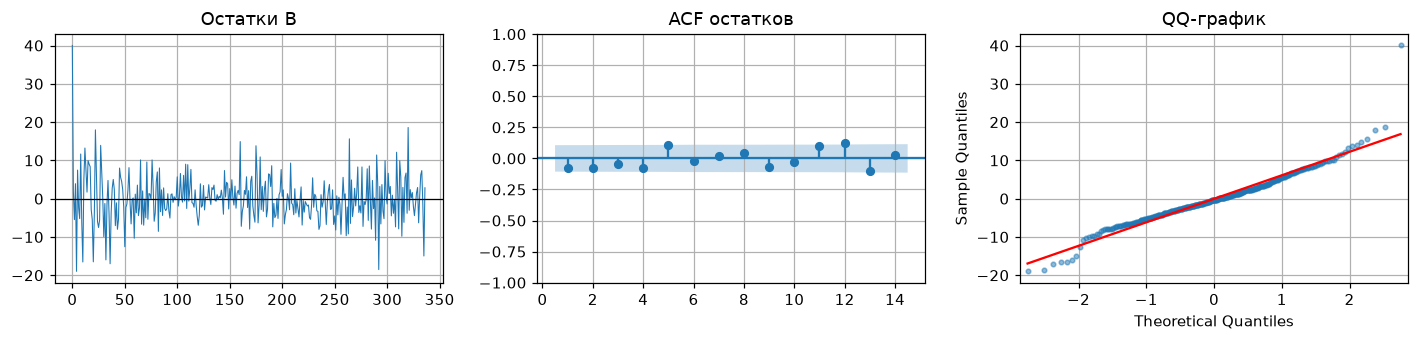

In [37]:
_ = residual_report(m_B.resid, n_params=sum(ORDER_B[::2]) + SORDER_B[0] + SORDER_B[2],
                    m=7, burn=14, title="B")

Остатки центрированы (среднее практически ноль), но Ljung–Box отвергается, и
на графике видны всплески — это дни экстремальной жары, когда спрос растёт
быстрее, чем описывает парабола. Кандидаты на улучшение здесь понятны: третья
степень температуры, лаг температуры (вчерашняя жара нагрела здание), признак
«волна жары третий день подряд». Мы их не добавляем — в кейсе B нас интересует
другой сюжет, — но в реальной работе шаг 7 отправил бы нас обратно на шаг 5,
ровно как в кейсе A.

## B.8. Шаг 8 — прогноз, интервалы и **сценарии**

Здесь кейс B принципиально отличается от A. Чтобы построить прогноз, модели
нужна температура на 14 дней вперёд, а её никто не знает. Сначала посмотрим
на «нечестный» вариант — подставим фактическую температуру тестового периода.
Это не прогноз, а **верхняя граница возможного качества**: столько модель
выдала бы при идеальном прогнозе погоды.

In [38]:
fc_B = StatsForecast([AutoARIMA(season_length=7, alias="B")], freq="D").forecast(
    df=df_B, h=H_B, X_df=X_df_B, level=[95]
)
fc_B0 = StatsForecast([AutoARIMA(season_length=7, alias="B0")], freq="D").forecast(
    df=df_B[["unique_id", "ds", "y"]], h=H_B, level=[95]
)

pd.concat([
    scoreboard(fc_base_B, y_te_B, ["SeasonalNaive"]),
    scoreboard(fc_B0, y_te_B, ["B0"]).rename(index={"B0": "SARIMA без регрессоров"}),
    scoreboard(fc_B, y_te_B, ["B"]).rename(index={"B": "SARIMAX + факт. температура"}),
]).round(2)

,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,23.57,29.03,12.97,100.00
SARIMA без регрессоров,23.75,30.47,13.04,85.71
SARIMAX + факт. температура,16.41,19.91,8.81,64.29


Регрессоры дают выигрыш почти в полтора раза по MAE. Но посмотрите на
**покрытие: 64 %** вместо заявленных 95 %. Интервал слишком узок — ровно то,
о чём предупреждал ноутбук `04`, раздел 6: в нём не учтена ни неопределённость
оценённых параметров, ни то, что структура ряда может измениться.

🔍 И это при том, что температуру мы подставили **точную**. В реальности будет
ещё хуже: ошибка прогноза погоды в интервал спроса не входит вообще (ноутбук
`05`, способ 4).

### Сценарный веер

Честный способ подать такой прогноз — не одна линия, а **несколько сценариев**
с явно названным допущением. Возьмём три температурных сценария: холодная
волна (−5 °C к норме), норма (сезонное среднее) и жара (+8 °C).

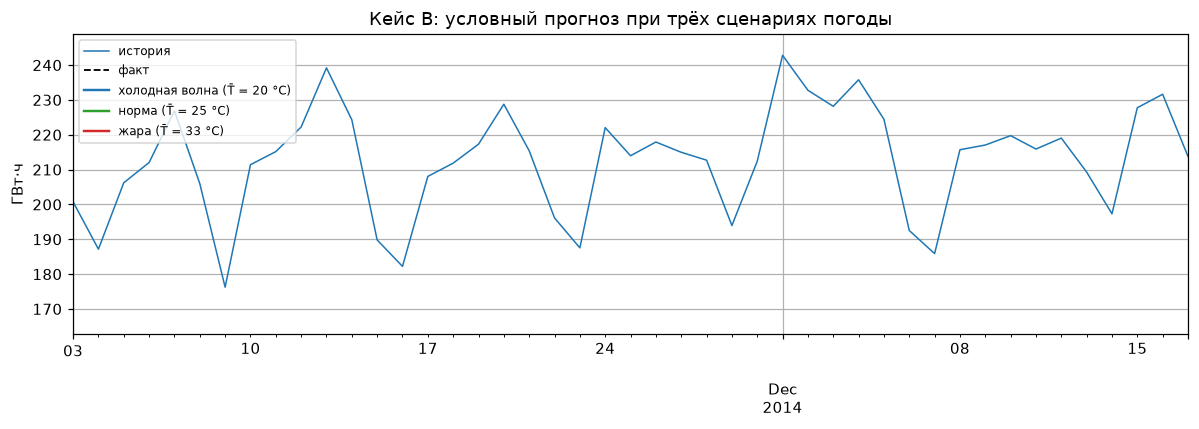

In [39]:
seasonal_norm = vic["Temperature"].rolling(15, center=True, min_periods=1).mean()
base_temp = seasonal_norm.iloc[-H_B:].values                 # «норма» для этих дат

scenarios = {"холодная волна": base_temp - 5, "норма": base_temp, "жара": base_temp + 8}

fig, ax = plt.subplots(figsize=(11, 4))
y_tr_B.iloc[-45:].plot(ax=ax, color="C0", lw=1.0, label="история")
ax.plot(y_te_B.index, y_te_B.values, color="k", ls="--", lw=1.2, label="факт")

for (name, temps), color in zip(scenarios.items(), ["C0", "C2", "C3"]):
    X_s = vic_exog(y_te_B.index, temps, vic["Holiday"].iloc[-H_B:])
    X_df_s = to_long(pd.Series(np.nan, index=y_te_B.index), X_s, uid="vic").drop(columns=["y"])
    fc_s = StatsForecast([AutoARIMA(season_length=7, alias="S")], freq="D").forecast(
        df=df_B, h=H_B, X_df=X_df_s, level=[95]
    )
    ax.plot(y_te_B.index, fc_s["S"], color=color, lw=1.6,
            label=f"{name} (T̄ = {temps.mean():.0f} °C)")

ax.set(title="Кейс B: условный прогноз при трёх сценариях погоды", ylabel="ГВт·ч", xlabel="")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

Разброс между сценариями — десятки гигаватт-часов, и он **шире**, чем
95 %-й интервал внутри любого отдельного сценария. Это и есть главный
практический вывод кейса: неопределённость регрессора здесь доминирует над
неопределённостью самой SARIMAX, а стандартный интервал её не видит.

Подпись к такому графику обязана содержать слово «при»: «прогноз спроса **при
температуре по норме**», а не «прогноз спроса».

## B.9. Шаг 9 — rolling-origin CV

Шесть окон по 14 дней, три конфигурации: бейзлайн, SARIMA без регрессоров,
SARIMAX с регрессорами.

⏱ **~10 с.**

In [40]:
df_B_cv = to_long(y_B, X_B, uid="vic")

cv_B = StatsForecast(
    models=[SeasonalNaive(season_length=7), AutoARIMA(season_length=7, alias="SARIMAX")], freq="D"
).cross_validation(df=df_B_cv, h=H_B, n_windows=6, step_size=H_B, level=[95])

cv_B0 = StatsForecast(
    models=[AutoARIMA(season_length=7, alias="SARIMA")], freq="D"
).cross_validation(df=df_B_cv[["unique_id", "ds", "y"]], h=H_B, n_windows=6, step_size=H_B, level=[95])

pd.concat([
    scoreboard(cv_B, cv_B["y"], ["SeasonalNaive", "SARIMAX"]),
    scoreboard(cv_B0, cv_B0["y"], ["SARIMA"]),
]).round(2)

,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,12.93,17.47,6.41,100.00
SARIMAX,8.17,11.25,4.01,91.67
SARIMA,11.75,16.65,5.89,96.43


На шести окнах: бейзлайн 6.4 % MAPE, SARIMA без регрессоров 5.9 %, SARIMAX с
температурой 4.0 %. Выигрыш от регрессоров подтверждается, а покрытие на
большем числе точек оказывается ближе к номиналу (92 % против 64 % на одном
окне) — ещё один довод в пользу того, что **одному сплиту верить нельзя**.

## B.10. Шаг 10 — вывод в бизнес-терминах

In [41]:
_ = business_summary(cv_B["y"], cv_B["SARIMAX"])

смещение: -0.8% от уровня ряда (умеренный перепрогноз)
разброс ошибки: 5.3% от уровня ряда (средняя дисперсия)
→ периодические излишки, растут складские расходы


**Вывод по кейсу B.** Температура — самый ценный регрессор в задаче: она
снижает ошибку в полтора раза и даёт физически осмысленные коэффициенты.
Но её саму надо откуда-то взять, и неопределённость этого «откуда-то» больше,
чем весь остальной шум модели. Поэтому результат подаётся веером сценариев, а
в отчёте фиксируется допущение о погоде. Решающим здесь оказался **шаг 8**.

---
# Кейс C. Помогает ли внешний индикатор?

Месячный оборот розничной торговли (`RTRD`) и два индикатора настроений:
индекс потребительских настроений Левады (`levada_IPN`) и поисковый индекс
(`poiskInd_corr`). Вопрос заказчика звучит как «давайте добавим индексы, они
же про потребление» — и ответ на него совсем не очевиден.

Горизонт — **12 месяцев**.

## C.1. Шаг 1 — EDA

наблюдений: 138   период: 2008-09 — 2020-02


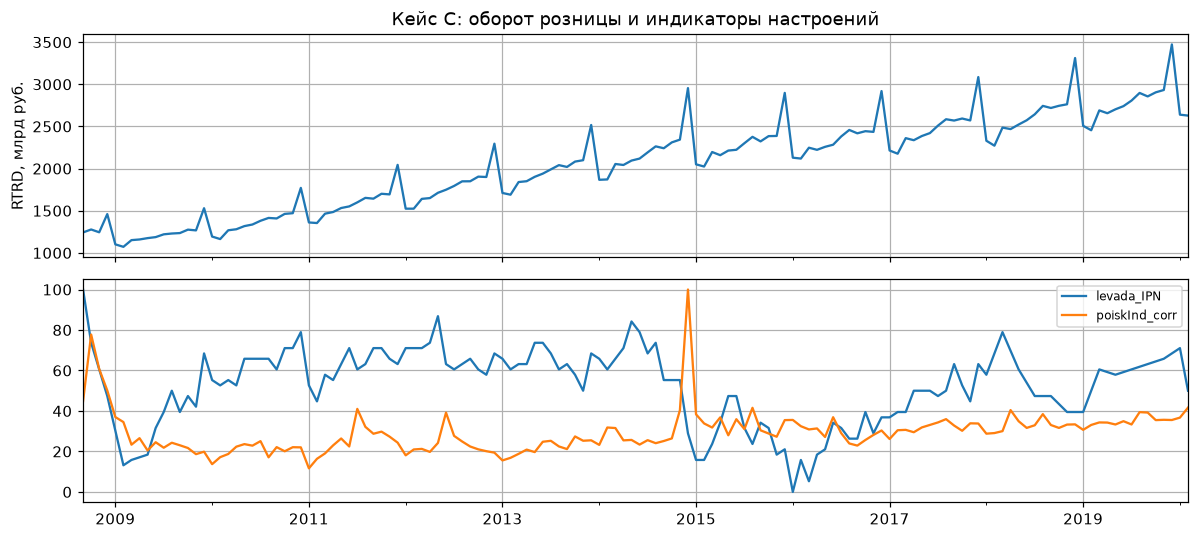

In [42]:
macro = pd.read_csv(DATA + "data.tsv", sep="\t", parse_dates=["fielddate"], index_col="fielddate")
macro = macro.dropna()                       # индекс Левады начинается позже остальных
macro.index.freq = "MS"

print(f"наблюдений: {len(macro)}   период: {macro.index[0]:%Y-%m} — {macro.index[-1]:%Y-%m}")

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
macro["RTRD"].plot(ax=axes[0], color="C0"); axes[0].set(ylabel="RTRD, млрд руб.")
macro[["levada_IPN", "poiskInd_corr"]].plot(ax=axes[1]); axes[1].set(xlabel="")
axes[0].set_title("Кейс C: оборот розницы и индикаторы настроений")
axes[1].legend(fontsize=8)
fig.tight_layout()

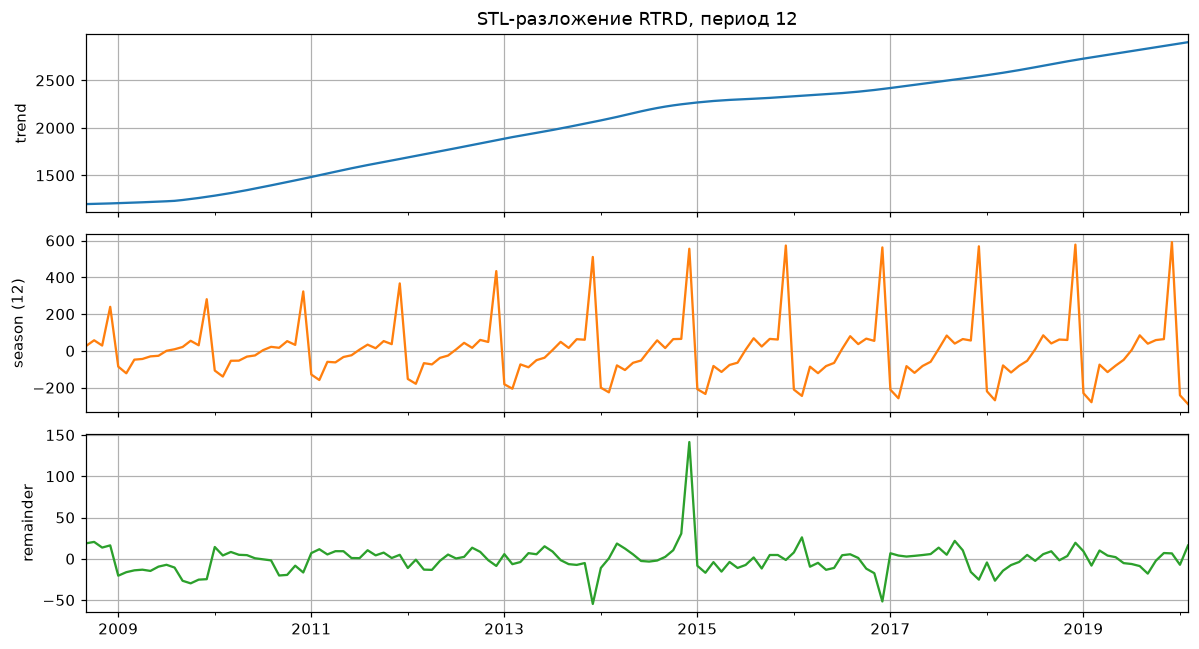

In [43]:
stl_C = STL(macro["RTRD"], period=12).fit()

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
stl_C.trend.plot(ax=axes[0], color="C0"); axes[0].set(ylabel="trend")
stl_C.seasonal.plot(ax=axes[1], color="C1"); axes[1].set(ylabel="season (12)")
stl_C.resid.plot(ax=axes[2], color="C2"); axes[2].set(ylabel="remainder", xlabel="")
axes[0].set_title("STL-разложение RTRD, период 12")
fig.tight_layout()

Три вещи бросаются в глаза:

1. сильная **годовая сезонность** с декабрьским пиком (предновогодние покупки);
2. растущий тренд, амплитуда сезонной волны растёт вместе с уровнем;
3. **аномалия конца 2014 — 2015 года**: валютный кризис. Посмотрим на неё
   отдельно.

In [44]:
print(macro.loc["2014-10":"2015-03", "RTRD"].round(0).to_string())
print("\nгодовой прирост, %:")
print((macro["RTRD"].pct_change(12) * 100).loc["2014-11":"2015-06"].round(1).to_string())

fielddate
2014-10-01    2311.0
2014-11-01    2344.0
2014-12-01    2955.0
2015-01-01    2050.0
2015-02-01    2024.0
2015-03-01    2197.0
Freq: MS

годовой прирост, %:
fielddate
2014-11-01    11.6
2014-12-01    17.4
2015-01-01     9.8
2015-02-01     8.2
2015-03-01     6.9
2015-04-01     5.7
2015-05-01     5.7
2015-06-01     4.9
Freq: MS


Декабрь 2014-го — ажиотажный спрос на фоне обвала рубля (+17 % год к году),
а весь 2015-й — резкое торможение (прирост падает с 12 % до 5 % и ниже).
Это **структурный сдвиг**, а не выброс в одной точке.

🔍 Правило из ноутбука `05`: структурный сдвиг лечится **дамми**, а не
дополнительной разностью. Лишняя разность «сгладит» сдвиг ценой того, что
модель станет шумнее на всей остальной истории.

## C.2. Шаг 2 — бейзлайн

In [45]:
H_C = 12
y_C = macro["RTRD"]

fc_base_C = StatsForecast([SeasonalNaive(season_length=12)], freq="MS").forecast(
    df=to_long(y_C.iloc[:-H_C], uid="rtrd"), h=H_C, level=[95]
)
scoreboard(fc_base_C, y_C.iloc[-H_C:], ["SeasonalNaive"]).round(2)

,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,165.97,167.08,5.91,100.0


## C.3. Шаг 3 — стабилизация дисперсии

In [46]:
roll_C = y_C.rolling(24)
print(f"corr(среднее, ст. откл.) = {np.corrcoef(roll_C.mean().dropna(), roll_C.std().dropna())[0, 1]:.2f}")
print(f"уровень вырос в {y_C.iloc[-12:].mean() / y_C.iloc[:12].mean():.1f} раза")
print(f"d на уровнях   = {ndiffs(y_C.values)},   D = {nsdiffs(y_C.values, period=12)}")
print(f"d на логарифме = {ndiffs(np.log(y_C.values))},   D = {nsdiffs(np.log(y_C.values), period=12)}")

corr(среднее, ст. откл.) = 0.81
уровень вырос в 2.3 раза
d на уровнях   = 1,   D = 1
d на логарифме = 1,   D = 1


Уровень вырос в 2.3 раза, амплитуда сезонной волны — вместе с ним. Это
классический мультипликативный ряд, и логарифм здесь напрашивается. Но
порядки дифференцирования он не меняет ($d=1$, $D=1$ в обоих случаях), а
сравнивать варианты надо по метрике. Чтобы не раздувать ноутбук, проверим
логарифм сразу на кросс-валидации в шаге 9 — вместе с остальными вариантами.

## C.4. Шаг 4 — `d` и `D`

Уже посчитано выше: $d = 1$, $D = 1$. Ряд нестационарен и по уровню, и
по сезонности — для месячной розницы это норма.

## C.5. Шаг 5 — кандидаты и главный вопрос кейса

Про порядки вопросов нет: ряд короткий (126 наблюдений), автоподбор
отработает за секунду. Главный вопрос другой — **какие регрессоры вообще
можно взять**.

🔑 Индексы настроений публикуются с задержкой и относятся к прошедшему
месяцу. Значит, прогнозируя на 12 месяцев вперёд, мы не знаем их значений
на горизонте. Единственный честный способ (способ 5 из ноутбука `05`) —
**лаг $k \ge h$**: взять `levada_IPN` и `poiskInd_corr` со сдвигом на 12
месяцев, тогда на всём горизонте они уже наблюдены.

Плюс дамми на кризис — событие в прошлом, размечается точно.

In [47]:
X_C = pd.DataFrame(
    {
        "lev12": macro["levada_IPN"].shift(12),          # лаг 12 = горизонту: известно бесплатно
        "poisk12": macro["poiskInd_corr"].shift(12),
        "crisis": ((macro.index >= "2014-11-01") & (macro.index <= "2015-12-01")).astype(float),
    },
    index=macro.index,
).dropna()

y_C = y_C.loc[X_C.index]                                 # выравниваем после сдвига
print(f"после сдвига осталось {len(y_C)} месяцев: {y_C.index[0]:%Y-%m} — {y_C.index[-1]:%Y-%m}")
X_C.head(3).round(2)

после сдвига осталось 126 месяцев: 2009-09 — 2020-02


,lev12,poisk12,crisis
fielddate,,,
2009-09-01,100.00,44.90,0.0
2009-10-01,73.68,77.75,0.0
2009-11-01,60.53,60.68,0.0


🔍 **Ловушка, которую легко не заметить.** Если задать лаг 1 вместо 12,
`statsforecast` спокойно отработает: в таблице есть столбцы, для горизонта они
заполнены, CV посчитается, метрики улучшатся. И всё это будет **утечкой** —
в реальном прогнозе на 12 месяцев значение индекса за 11-й месяц горизонта
взять неоткуда. Библиотека таких вещей не проверяет; проверять их — наша
работа. Правило простое: **для каждого столбца `exog` назовите, откуда возьмёте
его будущее значение.**

## C.6. Шаг 6 — подгонка и `summary()`

In [48]:
df_C = to_long(y_C, X_C, uid="rtrd")
y_tr_C, y_te_C = y_C.iloc[:-H_C], y_C.iloc[-H_C:]
X_tr_C, X_te_C = X_C.iloc[:-H_C], X_C.iloc[-H_C:]

sf_C = StatsForecast([AutoARIMA(season_length=12, alias="C")], freq="MS")
sf_C.fit(df=df_C.iloc[:-H_C])
print("выбранная спецификация:", arima_string(sf_C.fitted_[0, 0].model_))

ORDER_C, SORDER_C = (0, 1, 1), (0, 1, 0, 12)
m_C = SARIMAX(y_tr_C, exog=X_tr_C, order=ORDER_C, seasonal_order=SORDER_C).fit(disp=False)
print(m_C.summary().tables[1])

выбранная спецификация: Regression with ARIMA(0,1,1)(0,1,0)[12] errors
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
lev12         -0.0998      0.318     -0.314      0.754      -0.723       0.524
poisk12       -0.4958      0.240     -2.065      0.039      -0.966      -0.025
crisis        23.8897     14.182      1.685      0.092      -3.906      51.686
ma.L1         -0.4926      0.053     -9.312      0.000      -0.596      -0.389
sigma2      1593.9514    129.412     12.317      0.000    1340.309    1847.594


Читаем коэффициенты:

* `lev12` — практически ноль, p-value 0.75. Индекс Левады годичной давности
  оборот не объясняет;
* `poisk12` — отрицателен и **значим** (p-value 0.04);
* `crisis` — большой по величине (+24 млрд руб. в месяц), но p-value 0.09,
  то есть формально незначим.

🔑 Запомните эту картину, потому что на шаге 9 она **перевернётся**: значимый
`poisk12` ухудшит прогноз, а незначимый `crisis` улучшит его сильнее всего.

🔍 Противоречия здесь нет. P-value отвечает на вопрос «отличим ли эффект от
нуля на **этой** выборке», а нас интересует совсем другой — «уменьшится ли
ошибка на **новых** данных». Первый вопрос решается подгонкой, второй —
только кросс-валидацией, и ответы регулярно расходятся. Отбирать регрессоры
по звёздочкам в `summary()` — распространённая и дорогая ошибка.

## C.7. Шаг 7 — диагностика остатков

Ljung–Box (lags=24, model_df=1): stat = 11.3, p-value = 0.9804
среднее остатка = 0.6   ст. откл. = 40.1


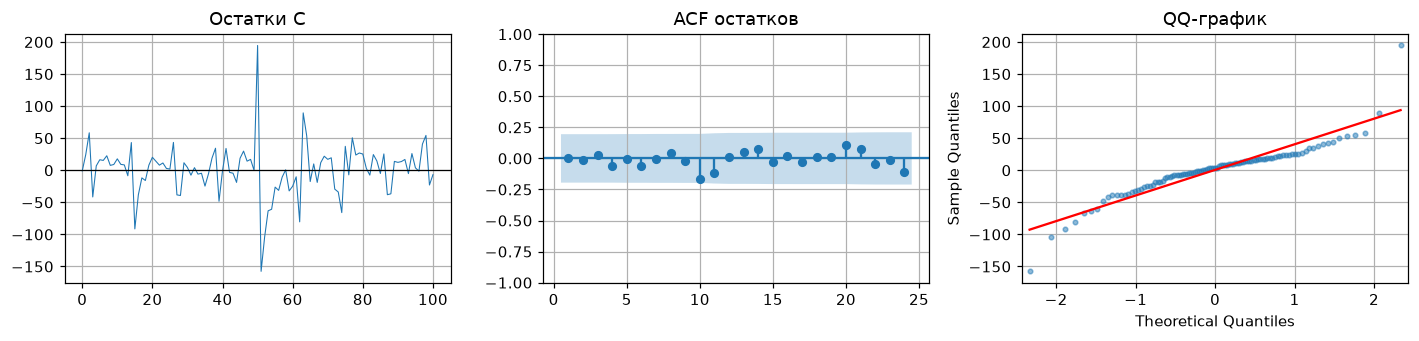

In [49]:
_ = residual_report(m_C.resid, n_params=ORDER_C[2], lags=24, m=12, burn=13, title="C")

## C.8. Шаг 8 — прогноз, интервалы, покрытие

In [50]:
X_df_C = to_long(pd.Series(np.nan, index=y_te_C.index), X_te_C, uid="rtrd").drop(columns=["y"])

fc_C = StatsForecast([AutoARIMA(season_length=12, alias="C")], freq="MS").forecast(
    df=df_C.iloc[:-H_C], h=H_C, X_df=X_df_C, level=[95]
)
fc_C0 = StatsForecast([AutoARIMA(season_length=12, alias="C0")], freq="MS").forecast(
    df=df_C.iloc[:-H_C][["unique_id", "ds", "y"]], h=H_C, level=[95]
)

pd.concat([
    scoreboard(fc_base_C, y_te_C, ["SeasonalNaive"]),
    scoreboard(fc_C0, y_te_C, ["C0"]).rename(index={"C0": "SARIMA без регрессоров"}),
    scoreboard(fc_C, y_te_C, ["C"]).rename(index={"C": "SARIMAX + индексы + кризис"}),
]).round(2)

,MAE,RMSE,"MAPE, %",покрытие 95%
SeasonalNaive,165.97,167.08,5.91,100.0
SARIMA без регрессоров,22.92,27.24,0.81,100.0
SARIMAX + индексы + кризис,25.71,29.81,0.91,100.0


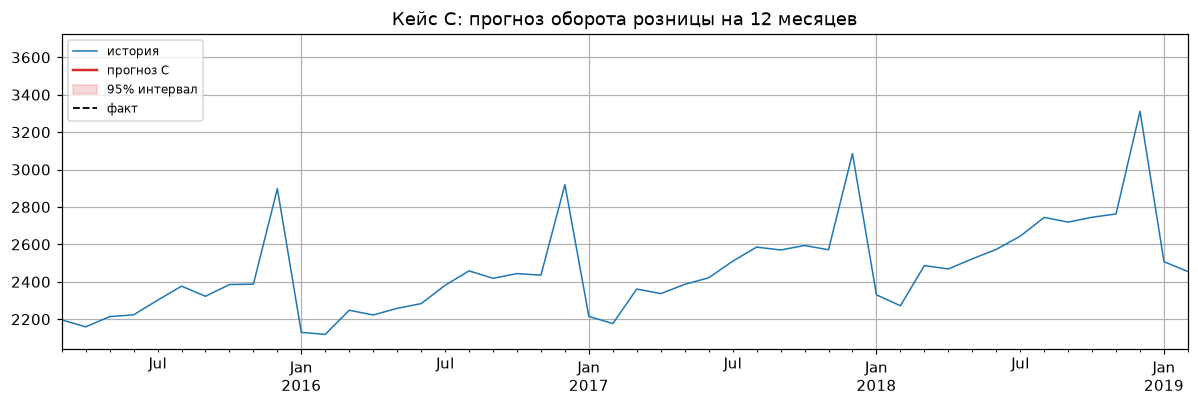

In [51]:
plot_forecast(y_tr_C, fc_C, "C", y_true=y_te_C, tail=48,
              title="Кейс C: прогноз оборота розницы на 12 месяцев")
plt.tight_layout()

Ряд прогнозируется хорошо: MAPE меньше 1 % против 5.9 % у бейзлайна. Но
регрессоры **не помогли** — модель с ними чуть хуже модели без них
(MAE 25.7 против 22.9). Пока это разница в пределах шума на одном окне; чтобы
сделать вывод, нужен шаг 9.

## C.9. Шаг 9 — CV: **здесь и решается судьба регрессоров**

Один сплит уже что-то показал, но именно в этом кейсе решение принимать по
нему нельзя: тестовое окно попадает на 2019 год, а кризисная дамми работает
на 2014–2015-м — на одном сплите её вклад просто не проверяется.

Прогоняем четыре окна по 12 месяцев и пять конфигураций:

1. бейзлайн `SeasonalNaive(12)`;
2. SARIMA без регрессоров;
3. SARIMA + индексы (лаг 12);
4. SARIMA + индексы + кризисная дамми;
5. SARIMA + **только** кризисная дамми.

⏱ **~5 с.**

In [52]:
CONFIGS = {
    "1. SeasonalNaive (бейзлайн)": ([], SeasonalNaive(season_length=12)),
    "2. SARIMA без регрессоров": ([], AutoARIMA(season_length=12)),
    "3. + индексы (лаг 12)": (["lev12", "poisk12"], AutoARIMA(season_length=12)),
    "4. + индексы + кризис": (["lev12", "poisk12", "crisis"], AutoARIMA(season_length=12)),
    "5. + только кризис": (["crisis"], AutoARIMA(season_length=12)),
}

rows = {}
for name, (cols, model) in CONFIGS.items():
    cv = StatsForecast([model], freq="MS").cross_validation(
        df=df_C[["unique_id", "ds", "y"] + cols], h=H_C, n_windows=4, step_size=H_C, level=[95]
    )
    alias = model.alias
    row = point_metrics(cv["y"], cv[alias])
    row["покрытие 95%"] = coverage(cv["y"], cv[f"{alias}-lo-95"], cv[f"{alias}-hi-95"])
    rows[name] = row

res_C = pd.DataFrame(rows).T
res_C["MAE в % от бейзлайна"] = 100 * res_C["MAE"] / res_C["MAE"].iloc[0]
res_C.round(1)

,MAE,RMSE,"MAPE, %",покрытие 95%,MAE в % от бейзлайна
1. SeasonalNaive (бейзлайн),129.6,137.7,4.9,100.0,100.0
2. SARIMA без регрессоров,38.7,48.0,1.5,100.0,29.9
3. + индексы (лаг 12),57.7,70.0,2.3,95.8,44.5
4. + индексы + кризис,60.6,98.6,2.4,97.9,46.8
5. + только кризис,25.2,31.8,1.0,100.0,19.5


🔑 **Два результата, и оба против интуиции.**

**Первый: индексы настроений ухудшают прогноз.** MAE растёт с 38.7 до 57.7 —
в полтора раза. И это при том, что коэффициент при `poisk12` был **значим**
на уровне 0.04 — ровно тот случай, о котором мы предупреждали на шаге 6.
Регрессор, который «логично должен помогать» и вдобавок прошёл тест на
значимость, на деле забирает степени свободы и вносит собственный шум.
Тот же сюжет был в исходном ноутбуке `5.6`: индексы описывают **настоящее**,
а не предсказывают будущее, и как только мы берём их с честным лагом
$k \ge h$, вся польза исчезает.

**Второй: дамми на кризис улучшает прогноз сильнее всего** — MAE падает
с 38.7 до 25.2, то есть в полтора раза, и это пятая часть ошибки бейзлайна.
Причём работает она не как «признак на будущее» (на горизонте она всегда
ноль), а как **чистка истории**: модель перестаёт считать аномальные месяцы
2014–2015 годов типичными и оценивает сезонность и тренд по нормальному
режиму.

🔍 И обратите внимание на строку 4: индексы **портят** даже вместе с
кризисной дамми (60.7 против 25.2). Вывод «добавим всё, пусть модель сама
разберётся» не работает: SARIMAX не делает отбора признаков.

### Проверка на устойчивость

Результат про дамми стоит перепроверить. Из-за сдвига на 12 месяцев мы
потеряли начало ряда — год с сентября 2008-го, а это разгар **предыдущего**
кризиса, 2008–2009 годов. Что будет, если вернуть эти месяцы в обучение?

Тестовые окна оставляем те же, меняется только длина истории.

In [53]:
i_full = macro.index
dummies_full = pd.DataFrame(
    {
        "crisis": ((i_full >= "2014-11-01") & (i_full <= "2015-12-01")).astype(float),
        "crisis08": ((i_full >= "2008-11-01") & (i_full <= "2009-12-01")).astype(float),
    },
    index=i_full,
)
df_C_full = to_long(macro["RTRD"], dummies_full, uid="rtrd")

rows = {}
for label, sub, cols in [
    ("126 мес. (с 2009-09), дамми на 2014-15", df_C[["unique_id", "ds", "y", "crisis"]], None),
    ("138 мес. (с 2008-09), без дамми", df_C_full, []),
    ("138 мес. (с 2008-09), дамми на 2014-15", df_C_full, ["crisis"]),
    ("138 мес., дамми на 2014-15 и 2008-09", df_C_full, ["crisis", "crisis08"]),
]:
    data = sub if cols is None else sub[["unique_id", "ds", "y"] + cols]
    model = AutoARIMA(season_length=12)
    cv = StatsForecast([model], freq="MS").cross_validation(
        df=data, h=H_C, n_windows=4, step_size=H_C, level=[95]
    )
    rows[label] = point_metrics(cv["y"], cv[model.alias])

pd.DataFrame(rows).T.round(1)

,MAE,RMSE,"MAPE, %"
"126 мес. (с 2009-09), дамми на 2014-15",25.2,31.8,1.0
"138 мес. (с 2008-09), без дамми",39.9,49.0,1.5
"138 мес. (с 2008-09), дамми на 2014-15",40.7,51.0,1.6
"138 мес., дамми на 2014-15 и 2008-09",34.2,44.5,1.3


🔑 **Вот это важно.** Стоит вернуть в обучение месяцы кризиса 2008–2009 — и
одна дамми перестаёт помогать совсем: 40.7 против 39.9 без неё. А стоит
разметить **и второй** кризис — выигрыш возвращается (34.2).

Механика простая: дамми говорит модели «эти месяцы не считать типичными».
Если в истории есть вторая такая же аномалия, а мы про неё не сказали, модель
всё равно оценивает дисперсию и сезонность по испорченным данным, и польза
от первой дамми тонет.

**Правило: аномалии размечают все сразу или не размечают вовсе.** И проверять
устойчивость вывода к длине обучающей выборки — часть шага 9, а не
необязательное дополнение.

## C.10. Шаг 10 — вывод в бизнес-терминах

In [54]:
cv_best = StatsForecast([AutoARIMA(season_length=12, alias="best")], freq="MS").cross_validation(
    df=df_C[["unique_id", "ds", "y", "crisis"]], h=H_C, n_windows=4, step_size=H_C, level=[95]
)
_ = business_summary(cv_best["y"], cv_best["best"])

смещение: +0.6% от уровня ряда (умеренный недопрогноз)
разброс ошибки: 1.1% от уровня ряда (низкая дисперсия)
→ редкие дефициты, управляемая потеря продаж


**Вывод по кейсу C.** Ответ заказчику: индексы потребительских настроений
добавлять **не нужно** — на честной проверке они ухудшают прогноз в полтора
раза. Зато нужно разметить период валютного кризиса: одна дамми-переменная
даёт выигрыш, которого не даёт ни один регрессор. Решающим оказался **шаг 9**:
без кросс-валидации мы бы приняли ровно противоположное решение.

---
# Итог: что показали три прогона

## Где решался исход

| Шаг | Кейс A (продажи) | Кейс B (спрос) | Кейс C (розница) |
|---|---|---|---|
| 1. EDA | две сезонности → Фурье | нет годовой → только $m=7$ | виден кризис 2014–15 |
| 2. Бейзлайн | `SeasonalNaive` хуже `Naive` | побит уверенно | побит в 5 раз |
| 3. Дисперсия | логарифм **не помог** | не нужен | нужен по виду, но не он решает |
| 4. `d`, `D` | $d=1, D=0$ | $d=1, D=1$ | $d=1, D=1$ |
| 5. Порядки | автоподбор | автоподбор | автоподбор |
| 6. `summary()` | β дамми = 33 тыс. руб. | минимум при 21 °C | значимость обманула |
| 7. Диагностика | 🔑 **нашла проблему** | нашла, но не пошли за ней | ок |
| 8. Интервалы | покрытие 89 → 96 % | 🔑 **сценарный веер** | ок |
| 9. CV | подтвердила | подтвердила | 🔑 **перевернула решение** |
| 10. Бизнес-вывод | 9 % MAPE на 4 недели | «при норме погоды» | «индексы не брать» |

Ни в одном кейсе исход не решил подбор `(p,q,P,Q)` — тот самый шаг, на который
обычно уходит больше всего времени. Решали данные и их разметка.

## Что нужно унести

1. **Чек-лист — цикл, а не конвейер.** В кейсе A возврат с шага 7 на шаг 5
   снизил MAPE с 14.9 % до 8.9 %. Если после диагностики вы ни разу не
   вернулись назад, скорее всего, вы просто не посмотрели на остатки.

2. **Бейзлайн обязателен, но бейзлайнов должно быть два.** В кейсе A
   `SeasonalNaive` оказался хуже `Naive` — и, взяв только его, мы бы решили,
   что модель хороша, хотя она едва обгоняла «завтра как сегодня».

3. **Шаг можно пропустить, но только с числом в руках.** Логарифм в кейсе A
   ухудшил бы результат, в кейсе B был не нужен вовсе. «На всякий случай» —
   не аргумент.

4. **Содержательный регрессор сильнее любой настройки порядков.** Две дамми
   на Новый год дали больше, чем весь перебор `(p,q,P,Q)`; температура в
   кейсе B — в полтора раза; кризисная дамми в кейсе C — тоже в полтора.

5. **Больше регрессоров ≠ лучше.** SARIMAX не отбирает признаки. В кейсе C
   два «логичных» индекса ухудшили прогноз в полтора раза, и вместе с полезной
   дамми — тоже.

6. **Значимость коэффициента не означает полезности признака.** В кейсе C
   `poisk12` был значим (p = 0.04) и ухудшил прогноз, а `crisis` был незначим
   (p = 0.09) и улучшил его сильнее всего. Отбирать регрессоры по
   `summary()` — дорогая ошибка; отбирают по CV.

7. **Аномалии размечают все сразу.** Одна дамми на кризис 2014–2015
   перестаёт работать, как только в обучении появляется неразмеченный кризис
   2008–2009.

8. **Для каждого столбца `exog` назовите источник его будущих значений.**
   Если не можете — это утечка, даже если код работает и метрики красивые.

9. **Покрытие интервала смотрим всегда.** В кейсе B точечный прогноз был
   отличный, а в 95 %-й интервал попадало 64 % фактов. Прогноз без честного
   интервала нельзя использовать для решений о запасах и мощностях.

10. **Решение принимается по rolling-origin CV** — и проверяется на
    устойчивость к длине истории. Один сплит — одно наблюдение.

## Карточка чек-листа

> 1. EDA: частота, пропуски, сезонности, STL.
> 2. Два бейзлайна: `Naive` и `SeasonalNaive`.
> 3. Дисперсия: проверить связь уровня и разброса, решение — по метрике.
> 4. `d`, `D` — тестами (`ndiffs`, `nsdiffs`), не критерием.
> 5. Порядки — стратегией под бюджет времени; $m$ большой → Фурье в `exog`.
> 6. `summary()`: знаки и масштабы $\beta$ проверить здравым смыслом.
> 7. Остатки: ACF, QQ, Ljung–Box с `model_df`, **посмотреть на худшие точки**.
> 8. Прогноз + интервал + покрытие; при сценарных `exog` — веер и подпись «при».
> 9. Rolling-origin CV против бейзлайна — это и есть решение.
> 10. Вывод: смещение и разброс в процентах от уровня, действие для заказчика.

---

На этом семинар 5 закончен. Дополнительный материал — ноутбук
`5.9. Conformal prediction`: что делать, когда аналитические интервалы
оказались слишком узкими (шаг 8 кейса B).